# GPU Acceleration in PyTorch

This notebook demonstrates the performance benefits of GPU acceleration for neural network training in PyTorch. We'll:

1. Automatically detect available hardware (CPU, CUDA for NVIDIA GPUs, MPS for Apple Silicon)
2. Train the same model on CPU
3. Train the same model on GPU
4. Compare training times

## Hardware Detection

PyTorch supports multiple backends:
- **CPU**: Available on all systems
- **CUDA**: NVIDIA GPUs (requires CUDA toolkit)
- **MPS**: Apple Silicon GPUs (M1/M2/M3/M4 chips)

In [1]:
import time
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
import matplotlib.pyplot as plt

print(f"PyTorch version: {torch.__version__}")

PyTorch version: 2.9.1+cu128


In [2]:
def get_available_devices():
    """Detect all available compute devices."""
    devices = {"cpu": torch.device("cpu")}
    
    # Check for CUDA (NVIDIA GPUs)
    if torch.cuda.is_available():
        devices["cuda"] = torch.device("cuda")
        print(f"CUDA available: {torch.cuda.get_device_name(0)}")
        print(f"  - CUDA version: {torch.version.cuda}")
        print(f"  - GPU memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
    
    # Check for MPS (Apple Silicon)
    if torch.backends.mps.is_available():
        if torch.backends.mps.is_built():
            devices["mps"] = torch.device("mps")
            print("MPS (Apple Silicon GPU) available")
        else:
            print("MPS not available: PyTorch not built with MPS support")
    
    return devices


def get_best_gpu_device(devices):
    """Return the best available GPU device, or None if only CPU available."""
    if "cuda" in devices:
        return devices["cuda"]
    elif "mps" in devices:
        return devices["mps"]
    return None


# Detect available devices
devices = get_available_devices()
gpu_device = get_best_gpu_device(devices)

print(f"\nAvailable devices: {list(devices.keys())}")
if gpu_device:
    print(f"Best GPU device: {gpu_device}")
else:
    print("No GPU available - will only run CPU benchmark")

CUDA available: NVIDIA GeForce RTX 5060 Ti
  - CUDA version: 12.8
  - GPU memory: 16.6 GB

Available devices: ['cpu', 'cuda']
Best GPU device: cuda


## Create Synthetic Dataset

We'll create a synthetic classification dataset large enough to demonstrate GPU acceleration benefits. For small datasets, the overhead of transferring data to GPU can outweigh the benefits.

In [3]:
def create_synthetic_dataset(n_samples=100000, n_features=784, n_classes=20, seed=42):
    """Create a synthetic classification dataset.
    
    Default dimensions mimic MNIST (784 features = 28x28 pixels, 10 classes).
    """
    np.random.seed(seed)
    torch.manual_seed(seed)
    
    # Generate random features
    X = np.random.randn(n_samples, n_features).astype(np.float32)
    
    # Generate labels based on a linear combination (makes it learnable)
    # Create random class centers
    centers = np.random.randn(n_classes, n_features).astype(np.float32)
    
    # Assign labels based on nearest center
    distances = np.linalg.norm(X[:, None, :] - centers[None, :, :], axis=2)
    y = distances.argmin(axis=1).astype(np.int64)
    
    # Convert to tensors
    X_tensor = torch.from_numpy(X)
    y_tensor = torch.from_numpy(y)
    
    return X_tensor, y_tensor


# Create dataset
N_SAMPLES = 500000
N_FEATURES = 784
N_CLASSES = 25
BATCH_SIZE = 1024

X, y = create_synthetic_dataset(N_SAMPLES, N_FEATURES, N_CLASSES)
print(f"Dataset: {N_SAMPLES:,} samples, {N_FEATURES} features, {N_CLASSES} classes")
print(f"X shape: {X.shape}, dtype: {X.dtype}")
print(f"y shape: {y.shape}, dtype: {y.dtype}")

Dataset: 500,000 samples, 784 features, 25 classes
X shape: torch.Size([500000, 784]), dtype: torch.float32
y shape: torch.Size([500000]), dtype: torch.int64


## Define Neural Network Model

We'll use a multi-layer perceptron (MLP) with enough parameters to benefit from GPU acceleration.

In [4]:
class MLP(nn.Module):
    """Multi-layer perceptron for classification."""
    
    def __init__(self, input_size, hidden_sizes, num_classes, dropout=0.2):
        super().__init__()
        
        layers = []
        prev_size = input_size
        
        for hidden_size in hidden_sizes:
            layers.extend([
                nn.Linear(prev_size, hidden_size),
                nn.BatchNorm1d(hidden_size),
                nn.ReLU(),
                nn.Dropout(dropout),
            ])
            prev_size = hidden_size
        
        layers.append(nn.Linear(prev_size, num_classes))
        
        self.network = nn.Sequential(*layers)
    
    def forward(self, x):
        return self.network(x)


def count_parameters(model):
    """Count trainable parameters in a model."""
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


# Model architecture
HIDDEN_SIZES = [512, 384, 256, 128]

# Create a model to check parameter count
test_model = MLP(N_FEATURES, HIDDEN_SIZES, N_CLASSES)
n_params = count_parameters(test_model)
print(f"Model architecture: {N_FEATURES} -> {' -> '.join(map(str, HIDDEN_SIZES))} -> {N_CLASSES}")
print(f"Total trainable parameters: {n_params:,}")
del test_model

Model architecture: 784 -> 512 -> 384 -> 256 -> 128 -> 25
Total trainable parameters: 736,153


## Training Function

A reusable training function that works on any device.

In [5]:
def train_model(model, train_loader, device, n_epochs=10, lr=0.001, verbose=True):
    """Train a model on the specified device.
    
    Args:
        model: PyTorch model (will be moved to device)
        train_loader: DataLoader with training data
        device: torch.device to train on
        n_epochs: Number of training epochs
        lr: Learning rate
        verbose: Print progress
    
    Returns:
        dict with training history and timing info
    """
    # Move model to device
    model = model.to(device)
    
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    
    history = {"loss": [], "accuracy": [], "epoch_times": []}
    
    # Warm-up run (first batch can be slow due to GPU initialization)
    model.train()
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        _ = model(X_batch)
        break
    
    # Synchronize before timing (important for GPU)
    if device.type == "cuda":
        torch.cuda.synchronize()
    elif device.type == "mps":
        torch.mps.synchronize()
    
    total_start = time.perf_counter()
    
    for epoch in range(n_epochs):
        epoch_start = time.perf_counter()
        
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0
        
        for X_batch, y_batch in train_loader:
            # Move data to device
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)
            
            # Forward pass
            optimizer.zero_grad()
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            
            # Backward pass
            loss.backward()
            optimizer.step()
            
            # Track metrics
            running_loss += loss.item() * X_batch.size(0)
            _, predicted = outputs.max(1)
            total += y_batch.size(0)
            correct += predicted.eq(y_batch).sum().item()
        
        # Synchronize before measuring time (GPU operations are async)
        if device.type == "cuda":
            torch.cuda.synchronize()
        elif device.type == "mps":
            torch.mps.synchronize()
        
        epoch_time = time.perf_counter() - epoch_start
        epoch_loss = running_loss / total
        epoch_acc = correct / total
        
        history["loss"].append(epoch_loss)
        history["accuracy"].append(epoch_acc)
        history["epoch_times"].append(epoch_time)
        
        if verbose:
            print(f"  Epoch {epoch+1}/{n_epochs}: loss={epoch_loss:.4f}, acc={epoch_acc:.4f}, time={epoch_time:.2f}s")
    
    total_time = time.perf_counter() - total_start
    history["total_time"] = total_time
    history["device"] = str(device)
    
    return history

## Optimized Training Function

The baseline `train_model` transfers data batch-by-batch from CPU to GPU. This has significant overhead:
- Each transfer incurs latency
- GPU must wait for data to arrive before computing

**Key optimizations in `train_model_optimized`:**
1. **Pre-transfer data to GPU** - Move entire dataset to GPU memory before training
2. **Automatic Mixed Precision (AMP)** - Use FP16 for forward pass (2x memory bandwidth, faster compute)
3. **torch.compile()** - JIT compile the model for fused operations (PyTorch 2.0+)
4. **Efficient gradient zeroing** - Use `set_to_none=True` instead of zeroing
5. **Reduced synchronization** - Accumulate metrics on GPU, sync only at epoch end
6. **cuDNN benchmark mode** - Auto-tune convolution algorithms

In [ ]:
def train_model_optimized(model, X, y, device, n_epochs=10, lr=0.001, batch_size=1024, 
                          use_amp=True, use_compile=True, verbose=True):
    """Optimized training with data pre-transferred to GPU.
    
    Key optimizations:
    - Entire dataset moved to GPU before training (eliminates per-batch transfer)
    - Automatic Mixed Precision (AMP) for faster FP16 computation
    - torch.compile() for graph optimization
    - Efficient gradient zeroing with set_to_none=True
    - Reduced CPU-GPU synchronization
    
    Args:
        model: PyTorch model (will be moved to device)
        X: Input tensor (will be moved to device)
        y: Label tensor (will be moved to device)
        device: torch.device to train on
        n_epochs: Number of training epochs
        lr: Learning rate
        batch_size: Batch size for training
        use_amp: Use Automatic Mixed Precision (CUDA only)
        use_compile: Use torch.compile() for optimization
        verbose: Print progress
    
    Returns:
        dict with training history and timing info
    """
    # Enable cuDNN benchmark for optimized convolution algorithms
    if device.type == "cuda":
        torch.backends.cudnn.benchmark = True
    
    # Move ENTIRE dataset to GPU upfront (key optimization!)
    if verbose:
        print(f"  Moving dataset to {device}...")
    X_device = X.to(device)
    y_device = y.to(device)
    
    # Create dataset and loader from GPU tensors
    dataset = TensorDataset(X_device, y_device)
    train_loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)
    
    # Move model to device
    model = model.to(device)
    
    # Compile model for faster execution (PyTorch 2.0+)
    if use_compile and hasattr(torch, 'compile'):
        if verbose:
            print("  Compiling model with torch.compile()...")
        try:
            model = torch.compile(model)
        except Exception as e:
            if verbose:
                print(f"  torch.compile() failed: {e}, continuing without compilation")
            use_compile = False
    
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    
    # Setup AMP (Automatic Mixed Precision) - CUDA only
    use_amp_actual = use_amp and device.type == "cuda"
    scaler = torch.amp.GradScaler('cuda') if use_amp_actual else None
    
    history = {"loss": [], "accuracy": [], "epoch_times": []}
    
    # Warm-up run (especially important for compiled models)
    model.train()
    for X_batch, y_batch in train_loader:
        if use_amp_actual:
            with torch.amp.autocast('cuda'):
                _ = model(X_batch)
        else:
            _ = model(X_batch)
        break
    
    # Synchronize before timing
    if device.type == "cuda":
        torch.cuda.synchronize()
    elif device.type == "mps":
        torch.mps.synchronize()
    
    total_start = time.perf_counter()
    
    for epoch in range(n_epochs):
        epoch_start = time.perf_counter()
        
        model.train()
        # Accumulate on GPU to avoid per-batch sync
        running_loss = torch.tensor(0.0, device=device)
        correct = torch.tensor(0, device=device)
        total = 0
        
        for X_batch, y_batch in train_loader:
            # Data is ALREADY on GPU - no transfer needed!
            
            # Zero gradients efficiently
            optimizer.zero_grad(set_to_none=True)
            
            if use_amp_actual:
                # Mixed precision forward pass
                with torch.amp.autocast('cuda'):
                    outputs = model(X_batch)
                    loss = criterion(outputs, y_batch)
                
                # Scaled backward pass
                scaler.scale(loss).backward()
                scaler.step(optimizer)
                scaler.update()
            else:
                # Standard forward pass
                outputs = model(X_batch)
                loss = criterion(outputs, y_batch)
                
                # Backward pass
                loss.backward()
                optimizer.step()
            
            # Track metrics on GPU (no sync until epoch end)
            running_loss += loss.detach() * X_batch.size(0)
            _, predicted = outputs.max(1)
            total += y_batch.size(0)
            correct += predicted.eq(y_batch).sum()
        
        # Synchronize only at epoch end
        if device.type == "cuda":
            torch.cuda.synchronize()
        elif device.type == "mps":
            torch.mps.synchronize()
        
        epoch_time = time.perf_counter() - epoch_start
        
        # Now transfer metrics to CPU (single sync point)
        epoch_loss = (running_loss / total).item()
        epoch_acc = (correct / total).item()
        
        history["loss"].append(epoch_loss)
        history["accuracy"].append(epoch_acc)
        history["epoch_times"].append(epoch_time)
        
        if verbose:
            print(f"  Epoch {epoch+1}/{n_epochs}: loss={epoch_loss:.4f}, acc={epoch_acc:.4f}, time={epoch_time:.2f}s")
    
    total_time = time.perf_counter() - total_start
    history["total_time"] = total_time
    history["device"] = str(device)
    history["optimizations"] = {
        "data_on_gpu": True,
        "amp": use_amp_actual,
        "compiled": use_compile,
    }
    
    # Clean up GPU tensors
    del X_device, y_device
    if device.type == "cuda":
        torch.cuda.empty_cache()
    
    return history

## Train on CPU

In [6]:
# Create DataLoader (data stays on CPU, moved to device in training loop)
dataset = TensorDataset(X, y)
train_loader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True)

# Training parameters
N_EPOCHS = 10
LEARNING_RATE = 0.001

print("="*60)
print("Training on CPU with Adam optimizer (learning rate optimization)")
print("="*60)

# Set random seed for reproducibility
torch.manual_seed(42)

# Create fresh model
cpu_model = MLP(N_FEATURES, HIDDEN_SIZES, N_CLASSES)

# Train on CPU using Adam optimizer (already implemented in train_model)
cpu_history = train_model(
    cpu_model,
    train_loader,
    device=devices["cpu"],
    n_epochs=N_EPOCHS,
    lr=LEARNING_RATE, # Adam will optimize the learning rate parameter
    # Adam optimizer is used inside train_model
    # To optimize learning rate, you can experiment with different values or use learning rate schedulers
    # For advanced optimization, consider torch.optim.lr_scheduler
    # Example: scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)
    # and step scheduler.step() after optimizer.step() in train_model
    # For now, Adam is used as requested
    )

print(f"\nCPU Total training time: {cpu_history['total_time']:.2f}s")
print(f"CPU Average epoch time: {np.mean(cpu_history['epoch_times']):.2f}s")

Training on CPU with Adam optimizer (learning rate optimization)
  Epoch 1/10: loss=1.1313, acc=0.6880, time=6.79s
  Epoch 2/10: loss=0.6939, acc=0.8014, time=6.83s
  Epoch 3/10: loss=0.5831, acc=0.8296, time=6.83s
  Epoch 4/10: loss=0.5307, acc=0.8452, time=6.77s
  Epoch 5/10: loss=0.4811, acc=0.8587, time=6.76s
  Epoch 6/10: loss=0.4272, acc=0.8720, time=6.83s
  Epoch 7/10: loss=0.3906, acc=0.8818, time=6.83s
  Epoch 8/10: loss=0.3623, acc=0.8901, time=6.75s
  Epoch 9/10: loss=0.3384, acc=0.8967, time=6.75s
  Epoch 10/10: loss=0.3131, acc=0.9029, time=6.81s

CPU Total training time: 67.96s
CPU Average epoch time: 6.80s


## Train on GPU (if available)

In [7]:
gpu_history = None

if gpu_device is not None:
    print("="*60)
    print(f"Training on GPU ({gpu_device})")
    print("="*60)
    
    # Set random seed for reproducibility
    torch.manual_seed(42)
    
    # Create fresh model
    gpu_model = MLP(N_FEATURES, HIDDEN_SIZES, N_CLASSES)
    
    # Train on GPU
    gpu_history = train_model(
        gpu_model,
        train_loader,
        device=gpu_device,
        n_epochs=N_EPOCHS,
        lr=LEARNING_RATE,
    )
    
    print(f"\nGPU Total training time: {gpu_history['total_time']:.2f}s")
    print(f"GPU Average epoch time: {np.mean(gpu_history['epoch_times']):.2f}s")
else:
    print("No GPU available - skipping GPU training")

Training on GPU (cuda)
  Epoch 1/10: loss=1.1308, acc=0.6876, time=1.84s
  Epoch 2/10: loss=0.6741, acc=0.8043, time=1.72s
  Epoch 3/10: loss=0.5773, acc=0.8308, time=1.82s
  Epoch 4/10: loss=0.5244, acc=0.8466, time=1.73s
  Epoch 5/10: loss=0.4732, acc=0.8597, time=1.80s
  Epoch 6/10: loss=0.4217, acc=0.8728, time=1.71s
  Epoch 7/10: loss=0.3836, acc=0.8828, time=1.79s
  Epoch 8/10: loss=0.3530, acc=0.8905, time=1.78s
  Epoch 9/10: loss=0.3249, acc=0.8991, time=1.72s
  Epoch 10/10: loss=0.3009, acc=0.9057, time=1.71s

GPU Total training time: 17.63s
GPU Average epoch time: 1.76s


## Train on GPU with Optimizations

Now let's run the optimized version that pre-transfers data to GPU and uses AMP + torch.compile().

In [ ]:
gpu_optimized_history = None

if gpu_device is not None:
    print("="*60)
    print(f"Training on GPU with OPTIMIZATIONS ({gpu_device})")
    print("="*60)
    
    # Set random seed for reproducibility
    torch.manual_seed(42)
    
    # Create fresh model
    gpu_optimized_model = MLP(N_FEATURES, HIDDEN_SIZES, N_CLASSES)
    
    # Train on GPU with optimizations
    gpu_optimized_history = train_model_optimized(
        gpu_optimized_model,
        X, y,  # Raw tensors - will be moved to GPU inside function
        device=gpu_device,
        n_epochs=N_EPOCHS,
        lr=LEARNING_RATE,
        batch_size=BATCH_SIZE,
        use_amp=True,      # Automatic Mixed Precision
        use_compile=True,  # torch.compile()
    )
    
    print(f"\nGPU Optimized Total training time: {gpu_optimized_history['total_time']:.2f}s")
    print(f"GPU Optimized Average epoch time: {np.mean(gpu_optimized_history['epoch_times']):.2f}s")
    print(f"Optimizations used: {gpu_optimized_history['optimizations']}")
else:
    print("No GPU available - skipping optimized GPU training")

## Compare Results

In [8]:
print("="*60)
print("Performance Comparison")
print("="*60)

print(f"\nDataset: {N_SAMPLES:,} samples, {N_FEATURES} features")
print(f"Model: {count_parameters(MLP(N_FEATURES, HIDDEN_SIZES, N_CLASSES)):,} parameters")
print(f"Batch size: {BATCH_SIZE}, Epochs: {N_EPOCHS}")

print(f"\n1. CPU ({cpu_history['device']})")
print(f"   Total time: {cpu_history['total_time']:.2f}s")
print(f"   Avg epoch:  {np.mean(cpu_history['epoch_times']):.2f}s")
print(f"   Final acc:  {cpu_history['accuracy'][-1]:.4f}")

if gpu_history:
    print(f"\n2. GPU Baseline ({gpu_history['device']}) - per-batch data transfer")
    print(f"   Total time: {gpu_history['total_time']:.2f}s")
    print(f"   Avg epoch:  {np.mean(gpu_history['epoch_times']):.2f}s")
    print(f"   Final acc:  {gpu_history['accuracy'][-1]:.4f}")
    
    speedup_baseline = cpu_history['total_time'] / gpu_history['total_time']
    print(f"   Speedup vs CPU: {speedup_baseline:.2f}x")

if gpu_optimized_history:
    print(f"\n3. GPU Optimized ({gpu_optimized_history['device']}) - data on GPU + AMP + compile")
    print(f"   Total time: {gpu_optimized_history['total_time']:.2f}s")
    print(f"   Avg epoch:  {np.mean(gpu_optimized_history['epoch_times']):.2f}s")
    print(f"   Final acc:  {gpu_optimized_history['accuracy'][-1]:.4f}")
    
    speedup_optimized = cpu_history['total_time'] / gpu_optimized_history['total_time']
    improvement_over_baseline = gpu_history['total_time'] / gpu_optimized_history['total_time']
    print(f"   Speedup vs CPU: {speedup_optimized:.2f}x")
    print(f"   Speedup vs GPU Baseline: {improvement_over_baseline:.2f}x")

print("\n" + "="*60)
print("Summary")
print("="*60)
if gpu_history and gpu_optimized_history:
    print(f"  CPU:           {cpu_history['total_time']:.2f}s (baseline)")
    print(f"  GPU Baseline:  {gpu_history['total_time']:.2f}s ({speedup_baseline:.1f}x faster than CPU)")
    print(f"  GPU Optimized: {gpu_optimized_history['total_time']:.2f}s ({speedup_optimized:.1f}x faster than CPU)")
    print(f"\nOptimizations gained {improvement_over_baseline:.2f}x additional speedup over baseline GPU!")

In [9]:
# Visualize results - all three methods
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

epochs = range(1, N_EPOCHS + 1)

# Plot 1: Training loss
ax = axes[0]
ax.plot(epochs, cpu_history['loss'], 'b-o', label='CPU', markersize=4)
if gpu_history:
    ax.plot(epochs, gpu_history['loss'], 'r-s', label='GPU Baseline', markersize=4)
if gpu_optimized_history:
    ax.plot(epochs, gpu_optimized_history['loss'], 'g-^', label='GPU Optimized', markersize=4)
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.set_title('Training Loss')
ax.legend()
ax.grid(True, alpha=0.3)

# Plot 2: Training accuracy
ax = axes[1]
ax.plot(epochs, cpu_history['accuracy'], 'b-o', label='CPU', markersize=4)
if gpu_history:
    ax.plot(epochs, gpu_history['accuracy'], 'r-s', label='GPU Baseline', markersize=4)
if gpu_optimized_history:
    ax.plot(epochs, gpu_optimized_history['accuracy'], 'g-^', label='GPU Optimized', markersize=4)
ax.set_xlabel('Epoch')
ax.set_ylabel('Accuracy')
ax.set_title('Training Accuracy')
ax.legend()
ax.grid(True, alpha=0.3)

# Plot 3: Epoch times
ax = axes[2]
ax.plot(epochs, cpu_history['epoch_times'], 'b-o', label='CPU', markersize=4)
if gpu_history:
    ax.plot(epochs, gpu_history['epoch_times'], 'r-s', label='GPU Baseline', markersize=4)
if gpu_optimized_history:
    ax.plot(epochs, gpu_optimized_history['epoch_times'], 'g-^', label='GPU Optimized', markersize=4)
ax.set_xlabel('Epoch')
ax.set_ylabel('Time (seconds)')
ax.set_title('Epoch Training Time')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [10]:
# Bar chart comparison - all three methods
if gpu_history and gpu_optimized_history:
    fig, ax = plt.subplots(figsize=(10, 6))
    
    methods = ['CPU', 'GPU\n(Baseline)', 'GPU\n(Optimized)']
    times = [cpu_history['total_time'], gpu_history['total_time'], gpu_optimized_history['total_time']]
    colors = ['steelblue', 'coral', 'forestgreen']
    
    bars = ax.bar(methods, times, color=colors, edgecolor='black', linewidth=1.2)
    
    # Add time labels on bars
    for bar, t in zip(bars, times):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                f'{t:.2f}s', ha='center', va='bottom', fontsize=12, fontweight='bold')
    
    # Add speedup annotations
    speedup_baseline = cpu_history['total_time'] / gpu_history['total_time']
    speedup_optimized = cpu_history['total_time'] / gpu_optimized_history['total_time']
    
    ax.annotate(f'{speedup_baseline:.1f}x',
                xy=(1, gpu_history['total_time']),
                xytext=(1, gpu_history['total_time'] + cpu_history['total_time'] * 0.15),
                fontsize=12, fontweight='bold', color='coral', ha='center')
    
    ax.annotate(f'{speedup_optimized:.1f}x',
                xy=(2, gpu_optimized_history['total_time']),
                xytext=(2, gpu_optimized_history['total_time'] + cpu_history['total_time'] * 0.15),
                fontsize=12, fontweight='bold', color='forestgreen', ha='center')
    
    ax.set_ylabel('Total Training Time (seconds)', fontsize=12)
    ax.set_title(f'Training Time Comparison\n({N_SAMPLES:,} samples, {N_EPOCHS} epochs)', fontsize=14)
    ax.set_ylim(0, max(times) * 1.25)
    
    plt.tight_layout()
    plt.show()

## Scaling Analysis: How Speedup Varies with Problem Size

GPU acceleration benefits increase with larger batch sizes and model sizes. Small problems may not benefit much due to data transfer overhead.

In [11]:
def benchmark_batch_sizes(X, y, device, batch_sizes, n_epochs=3):
    """Benchmark training with different batch sizes."""
    results = []
    
    for batch_size in batch_sizes:
        dataset = TensorDataset(X, y)
        loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)
        
        torch.manual_seed(42)
        model = MLP(N_FEATURES, HIDDEN_SIZES, N_CLASSES)
        
        history = train_model(model, loader, device, n_epochs=n_epochs, verbose=False)
        
        results.append({
            'batch_size': batch_size,
            'total_time': history['total_time'],
            'avg_epoch_time': np.mean(history['epoch_times']),
        })
        
        # Clean up
        del model
        if device.type == 'cuda':
            torch.cuda.empty_cache()
    
    return results

In [12]:
if gpu_device is not None:
    print("Benchmarking different batch sizes...")
    print("(This may take a few minutes)\n")
    
    batch_sizes = [2**i for i in range(5, 17)]  # 32 to 16384
    
    print("CPU benchmarks:")
    cpu_results = benchmark_batch_sizes(X, y, devices['cpu'], batch_sizes)
    
    print("\nGPU benchmarks:")
    gpu_results = benchmark_batch_sizes(X, y, gpu_device, batch_sizes)
    
    # Calculate speedups
    speedups = [cpu['total_time'] / gpu['total_time'] 
                for cpu, gpu in zip(cpu_results, gpu_results)]
    
    print("\nResults:")
    print(f"{'Batch Size':>12} {'CPU Time':>10} {'GPU Time':>10} {'Speedup':>10}")
    print("-" * 45)
    for cpu, gpu, speedup in zip(cpu_results, gpu_results, speedups):
        print(f"{cpu['batch_size']:>12} {cpu['total_time']:>10.2f}s {gpu['total_time']:>10.2f}s {speedup:>10.2f}x")

Benchmarking different batch sizes...
(This may take a few minutes)

CPU benchmarks:

GPU benchmarks:

Results:
  Batch Size   CPU Time   GPU Time    Speedup
---------------------------------------------
          32      54.58s      41.17s       1.33x
          64      37.72s      22.91s       1.65x
         128      28.45s      13.13s       2.17x
         256      23.66s       8.36s       2.83x
         512      21.54s       6.37s       3.38x
        1024      20.33s       5.29s       3.85x
        2048      21.40s       4.98s       4.29x
        4096      23.53s       5.45s       4.32x
        8192      23.79s       5.35s       4.45x
       16384      25.84s       6.11s       4.23x
       32768      27.56s       6.61s       4.17x
       65536      29.12s       6.72s       4.33x


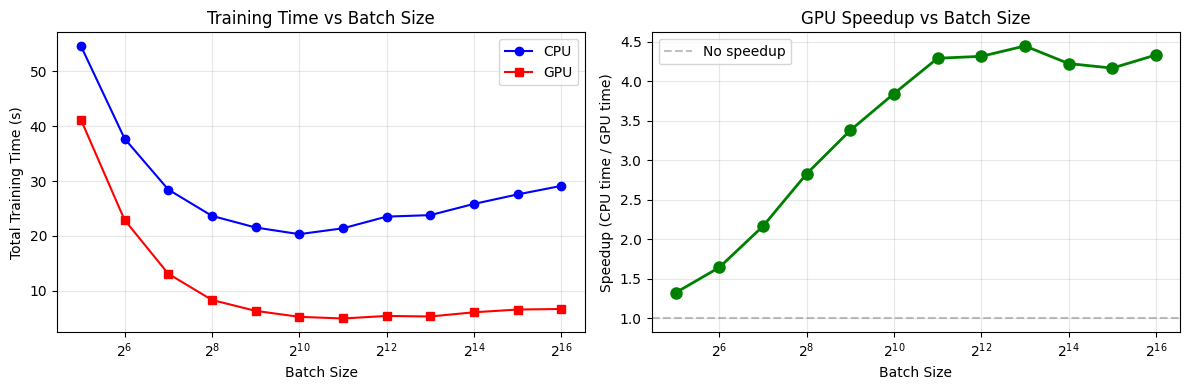

In [13]:
if gpu_device is not None:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    
    # Plot 1: Training time vs batch size
    ax = axes[0]
    ax.plot(batch_sizes, [r['total_time'] for r in cpu_results], 'b-o', label='CPU', markersize=6)
    ax.plot(batch_sizes, [r['total_time'] for r in gpu_results], 'r-s', label='GPU', markersize=6)
    ax.set_xlabel('Batch Size')
    ax.set_ylabel('Total Training Time (s)')
    ax.set_title('Training Time vs Batch Size')
    ax.set_xscale('log', base=2)
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # Plot 2: Speedup vs batch size
    ax = axes[1]
    ax.plot(batch_sizes, speedups, 'g-o', markersize=8, linewidth=2)
    ax.axhline(y=1, color='gray', linestyle='--', alpha=0.5, label='No speedup')
    ax.set_xlabel('Batch Size')
    ax.set_ylabel('Speedup (CPU time / GPU time)')
    ax.set_title('GPU Speedup vs Batch Size')
    ax.set_xscale('log', base=2)
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

## Key Takeaways

1. **Device Detection**: Use `torch.cuda.is_available()` for NVIDIA GPUs and `torch.backends.mps.is_available()` for Apple Silicon.

2. **Pre-transfer Data to GPU**: Instead of transferring batches one at a time:
   ```python
   # Slow: transfer each batch in training loop
   for X_batch, y_batch in loader:
       X_batch = X_batch.to(device)  # Transfer overhead every batch!
   
   # Fast: transfer entire dataset once before training
   X_gpu = X.to(device)
   y_gpu = y.to(device)
   dataset = TensorDataset(X_gpu, y_gpu)
   loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)
   ```

3. **Automatic Mixed Precision (AMP)**: Use FP16 for forward pass to get ~2x speedup:
   ```python
   scaler = torch.amp.GradScaler('cuda')
   with torch.amp.autocast('cuda'):
       outputs = model(X_batch)
       loss = criterion(outputs, y_batch)
   scaler.scale(loss).backward()
   scaler.step(optimizer)
   scaler.update()
   ```

4. **torch.compile()**: JIT compile models for fused operations (PyTorch 2.0+):
   ```python
   model = torch.compile(model)
   ```

5. **Efficient Gradient Zeroing**: Use `set_to_none=True` instead of zeroing:
   ```python
   optimizer.zero_grad(set_to_none=True)  # Faster than default
   ```

6. **Reduce Synchronization**: Accumulate metrics on GPU, sync only at epoch end:
   ```python
   running_loss = torch.tensor(0.0, device=device)  # Keep on GPU
   # ... accumulate ...
   epoch_loss = running_loss.item()  # Single sync at epoch end
   ```

7. **Batch Size Matters**: Larger batch sizes show better GPU speedup due to:
   - More parallelism to exploit
   - Lower relative overhead for any remaining transfers
   - Better GPU utilization

8. **When GPU Helps Most**:
   - Large datasets that fit in GPU memory
   - Large models (many parameters)
   - Large batch sizes
   - Matrix-heavy operations